In [13]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Ensure local directories exist for the dataset
os.makedirs("housing_dataset/images", exist_ok=True)

In [14]:
print("Generating synthetic multimodal housing dataset...")
NUM_SAMPLES = 200

# 1. Create Tabular Features: SqFt, Bedrooms, Bathrooms, Age
sqft = np.random.randint(800, 5000, size=NUM_SAMPLES)
bedrooms = np.random.randint(1, 6, size=NUM_SAMPLES)
bathrooms = np.random.randint(1, 4, size=NUM_SAMPLES)
age = np.random.randint(0, 50, size=NUM_SAMPLES)

# Define a deterministic price formula with some added Gaussian noise
prices = (sqft * 155) + (bedrooms * 12000) + (bathrooms * 18000) - (age * 600) + np.random.normal(0, 15000, NUM_SAMPLES)

# Save to CSV
df = pd.DataFrame({
    'id': range(NUM_SAMPLES),
    'sqft': sqft,
    'bedrooms': bedrooms,
    'bathrooms': bathrooms,
    'age': age,
    'price': prices
})
df.to_csv("housing_dataset/tabular_data.csv", index=False)

# 2. Create Synthetic Images (Random color blocks as image placeholders)
for i in range(NUM_SAMPLES):
    img_array = np.random.randint(0, 255, (64, 64, 3), dtype=np.uint8)
    img = Image.fromarray(img_array)
    img.save(f"housing_dataset/images/house_{i}.jpg")

print(f"Successfully generated {NUM_SAMPLES} tabular records and matching images.\n")

Generating synthetic multimodal housing dataset...
Successfully generated 200 tabular records and matching images.



In [15]:
# Load tabular dataset
data = pd.read_csv("housing_dataset/tabular_data.csv")
X_tabular = data[['sqft', 'bedrooms', 'bathrooms', 'age']].values
y_targets = data['price'].values
image_ids = data['id'].values

# Train/Test Split
X_tab_train, X_tab_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X_tabular, y_targets, image_ids, test_size=0.2, random_state=42
)

# Standardize numerical features
scaler = StandardScaler()
X_tab_train = scaler.fit_transform(X_tab_train)
X_tab_test = scaler.transform(X_tab_test)

# PyTorch Multimodal Dataset Implementation
class MultimodalHousingDataset(Dataset):
    def __init__(self, tabular_features, targets, img_ids, img_dir, transform=None):
        self.tabular_features = torch.tensor(tabular_features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)
        self.img_ids = img_ids
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        # Match tabular records to image files using the 'id' index column
        img_name = f"house_{self.img_ids[idx]}.jpg"
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        tabular = self.tabular_features[idx]
        target = self.targets[idx]

        return image, tabular, target

# Transformation pipeline for image inputs
image_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Instantiate DataLoaders
img_directory = "housing_dataset/images"
train_dataset = MultimodalHousingDataset(X_tab_train, y_train, ids_train, img_directory, transform=image_transforms)
test_dataset = MultimodalHousingDataset(X_tab_test, y_test, ids_test, img_directory, transform=image_transforms)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [16]:
class MultimodalFusionNet(nn.Module):
    def __init__(self, num_tabular_features):
        super(MultimodalFusionNet, self).__init__()

        # 1. Image CNN Branch
        self.cnn_branch = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # State: 16 x 32 x 32

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # State: 32 x 16 x 16

            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 64),
            nn.ReLU()
        )

        # 2. Tabular MLP Branch
        self.mlp_branch = nn.Sequential(
            nn.Linear(num_tabular_features, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU()
        )

        # 3. Late Fusion Layer & Final Regressor
        self.regressor = nn.Sequential(
            nn.Linear(64 + 32, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # Single output for predicted price
        )

    def forward(self, image, tabular):
        # Extract features from both modalities
        img_feats = self.cnn_branch(image)
        tab_feats = self.mlp_branch(tabular)

        # Concatenate features along the column dimension (late fusion)
        fused_feats = torch.cat((img_feats, tab_feats), dim=1)

        # Predict price
        output = self.regressor(fused_feats)
        return output.squeeze(-1)

# Initialize model, loss, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultimodalFusionNet(num_tabular_features=4).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

print(f"Training architecture using hardware backend: {device}")

# Training Loop
epochs = 50
model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for images, tabulars, targets in train_loader:
        images, tabulars, targets = images.to(device), tabulars.to(device), targets.to(device)

        optimizer.zero_grad()
        predictions = model(images, tabulars)
        loss = criterion(predictions, targets)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * images.size(0)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | Avg Training MSE Loss: {epoch_loss / len(train_dataset):.2f}")

Training architecture using hardware backend: cpu
Epoch 10/50 | Avg Training MSE Loss: 32580255948.80
Epoch 20/50 | Avg Training MSE Loss: 31521807155.20
Epoch 30/50 | Avg Training MSE Loss: 22500920422.40
Epoch 40/50 | Avg Training MSE Loss: 8346029977.60
Epoch 50/50 | Avg Training MSE Loss: 2051349161.60


In [17]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for images, tabulars, targets in test_loader:
        images, tabulars = images.to(device), tabulars.to(device)
        predictions = model(images, tabulars)

        all_preds.extend(predictions.cpu().numpy())
        all_targets.extend(targets.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# Calculate mandatory validation regression metrics
mae = mean_absolute_error(all_targets, all_preds)
rmse = np.sqrt(mean_squared_error(all_targets, all_preds))

print("\n--- Final Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")


--- Final Model Evaluation Metrics ---
Mean Absolute Error (MAE): $38,611.07
Root Mean Squared Error (RMSE): $52,109.26


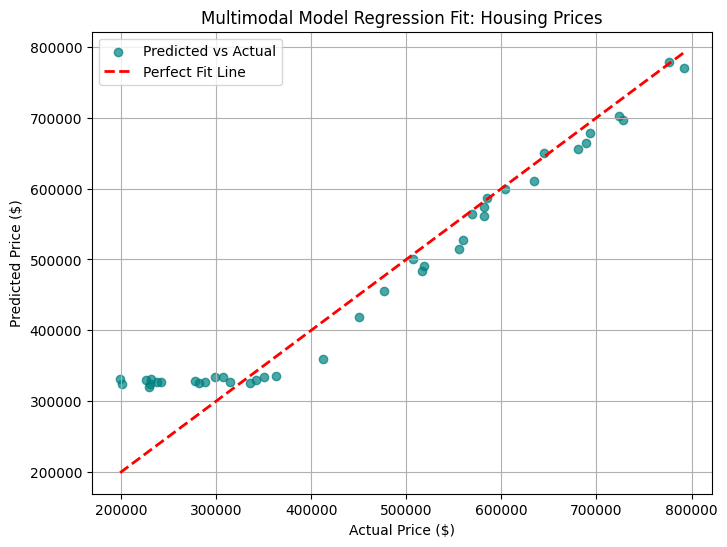

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(all_targets, all_preds, alpha=0.7, color='teal', label='Predicted vs Actual')
plt.plot([all_targets.min(), all_targets.max()], [all_targets.min(), all_targets.max()], 'r--', lw=2, label='Perfect Fit Line')
plt.title('Multimodal Model Regression Fit: Housing Prices')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.grid(True)
plt.show()